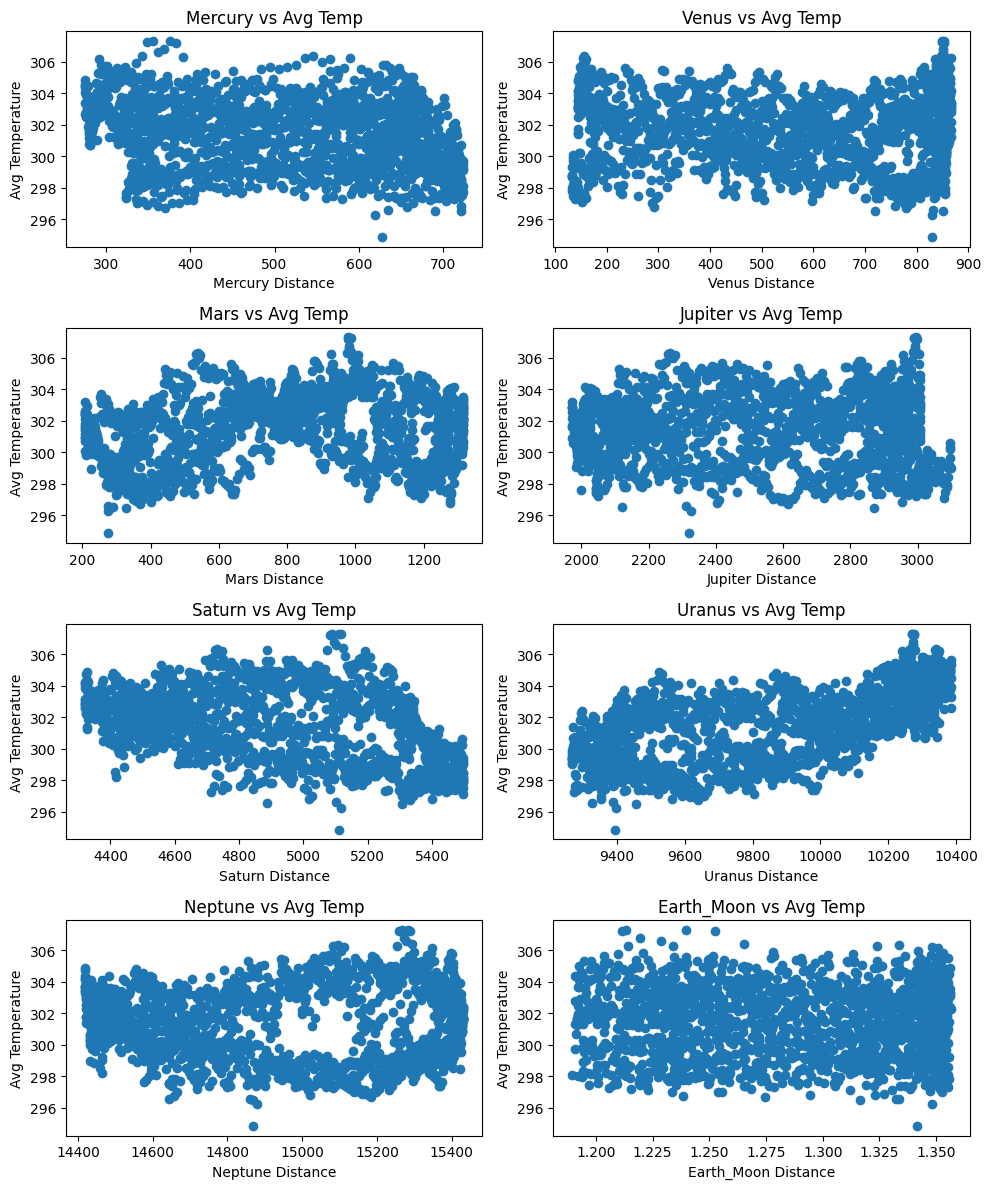

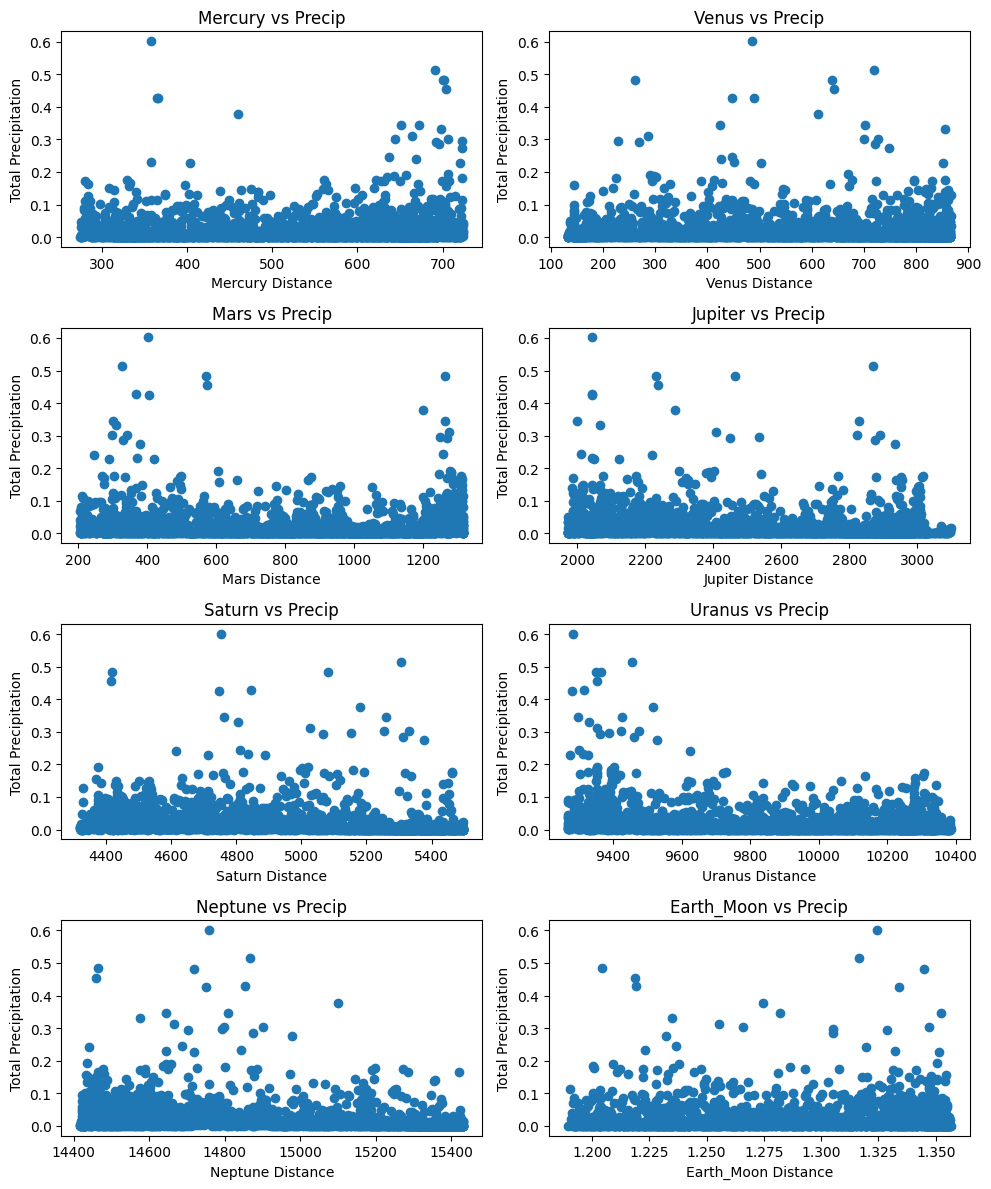

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("./assets/Dataset/weather_planets.csv")

# Make sure day is datetime
df["day"] = pd.to_datetime(df["day"])

planet_cols = [
    "Mercury", "Venus", "Mars", "Jupiter",
    "Saturn", "Uranus", "Neptune", "Earth_Moon"
]

# Layout: 4 rows x 2 columns
rows = 4
cols = 2

# ================================
# 1. Planets vs Average Temperature
# ================================

fig1, axes1 = plt.subplots(rows, cols, figsize=(10, 12))
axes1 = axes1.flatten()

for i, planet in enumerate(planet_cols):
    axes1[i].scatter(df[planet], df["avg_temp"])
    axes1[i].set_xlabel(f"{planet} Distance")
    axes1[i].set_ylabel("Avg Temperature")
    axes1[i].set_title(f"{planet} vs Avg Temp")

plt.tight_layout()
plt.show()

# ================================
# 2. Planets vs Precipitation
# ================================

fig2, axes2 = plt.subplots(rows, cols, figsize=(10, 12))
axes2 = axes2.flatten()

for i, planet in enumerate(planet_cols):
    axes2[i].scatter(df[planet], df["total_precip"])
    axes2[i].set_xlabel(f"{planet} Distance")
    axes2[i].set_ylabel("Total Precipitation")
    axes2[i].set_title(f"{planet} vs Precip")

plt.tight_layout()
plt.show()


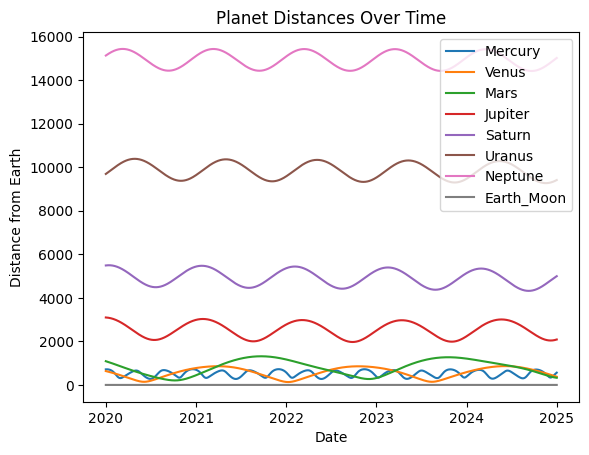

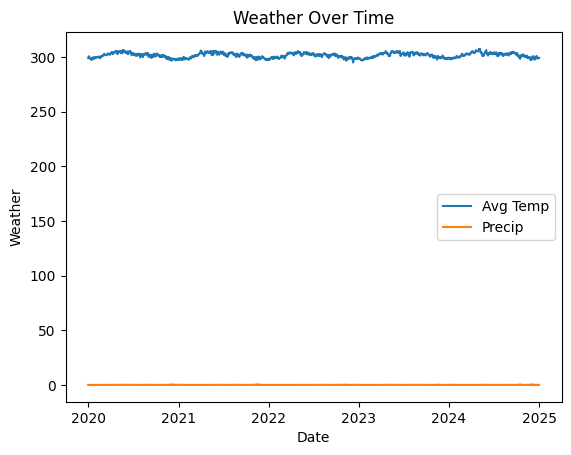

In [18]:
# ================================
# 2. Time series plots
# ================================

plt.figure()
for planet in planet_cols:
    plt.plot(df["day"], df[planet], label=planet)
plt.xlabel("Date")
plt.ylabel("Distance from Earth")
plt.title("Planet Distances Over Time")
plt.legend()
plt.show()

plt.figure()
plt.plot(df["day"], df["avg_temp"], label="Avg Temp")
plt.plot(df["day"], df["total_precip"], label="Precip")
plt.xlabel("Date")
plt.ylabel("Weather")
plt.title("Weather Over Time")
plt.legend()
plt.show()


In [19]:
# ================================
# 3. Correlation coefficients
# ================================

print("\nCorrelation with Temperature:\n")
for planet in planet_cols:
    corr = df[planet].corr(df["avg_temp"])
    print(f"{planet}: {corr:.4f}")

print("\nCorrelation with Precipitation:\n")
for planet in planet_cols:
    corr = df[planet].corr(df["total_precip"])
    print(f"{planet}: {corr:.4f}")


Correlation with Temperature:

Mercury: -0.2137
Venus: -0.0561
Mars: 0.1711
Jupiter: 0.0101
Saturn: -0.4217
Uranus: 0.6225
Neptune: 0.0036
Earth_Moon: -0.0242

Correlation with Precipitation:

Mercury: 0.0695
Venus: -0.0249
Mars: -0.0408
Jupiter: -0.1772
Saturn: -0.1623
Uranus: -0.2274
Neptune: -0.2563
Earth_Moon: 0.0058


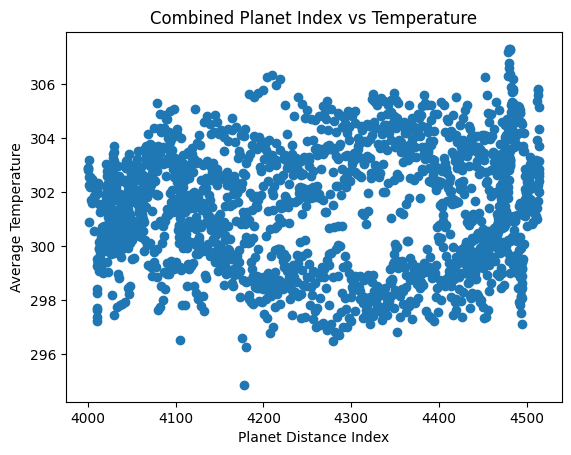

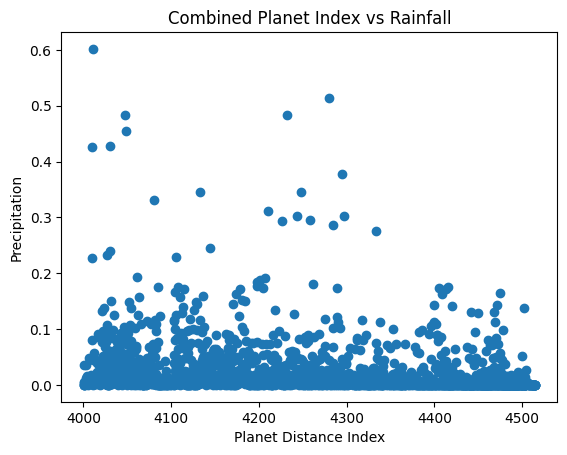

In [21]:
# Create a combined planetary distance index
df["planet_index"] = df[planet_cols].mean(axis=1)

# Plot vs temperature
plt.figure()
plt.scatter(df["planet_index"], df["avg_temp"])
plt.xlabel("Planet Distance Index")
plt.ylabel("Average Temperature")
plt.title("Combined Planet Index vs Temperature")
plt.show()

# Plot vs precipitation
plt.figure()
plt.scatter(df["planet_index"], df["total_precip"])
plt.xlabel("Planet Distance Index")
plt.ylabel("Precipitation")
plt.title("Combined Planet Index vs Rainfall")
plt.show()
